<a href="https://colab.research.google.com/github/Minal-2007/PROJECTS-/blob/main/Automobile%20service%20cost%20analyzer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_csv("/content/vehicle_maintenance_data.csv")

In [ ]:
df.head()

,Vehicle_Model,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance
0,Truck,58765,Good,0,4,Electric,Automatic,2000,28524,2023-11-23,2025-06-24,Second,20782,6,3,13.622204,New,New,Weak,1
1,Van,60353,Average,1,7,Electric,Automatic,2500,133630,2023-09-21,2025-06-04,Second,23489,7,0,13.625307,New,New,Weak,1
2,Bus,68072,Poor,0,2,Electric,Automatic,1500,34022,2023-06-27,2025-04-27,First,17979,7,0,14.306302,New,Good,Weak,1
3,Bus,60849,Average,4,5,Petrol,Automatic,2500,81636,2023-08-24,2025-11-05,Second,6220,7,3,18.709467,New,Worn Out,New,1
4,Bus,45742,Poor,5,1,Petrol,Manual,2000,97162,2023-05-25,2025-09-14,Third,16446,6,2,16.977482,Good,Good,Weak,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Vehicle_Model         50000 non-null  object 
 1   Mileage               50000 non-null  int64  
 2   Maintenance_History   50000 non-null  object 
 3   Reported_Issues       50000 non-null  int64  
 4   Vehicle_Age           50000 non-null  int64  
 5   Fuel_Type             50000 non-null  object 
 6   Transmission_Type     50000 non-null  object 
 7   Engine_Size           50000 non-null  int64  
 8   Odometer_Reading      50000 non-null  int64  
 9   Last_Service_Date     50000 non-null  object 
 10  Warranty_Expiry_Date  50000 non-null  object 
 11  Owner_Type            50000 non-null  object 
 12  Insurance_Premium     50000 non-null  int64  
 13  Service_History       50000 non-null  int64  
 14  Accident_History      50000 non-null  int64  
 15  Fuel_Efficiency    

In [7]:
df.isnull()

,Vehicle_Model,Mileage,Maintenance_History,Reported_Issues,Vehicle_Age,Fuel_Type,Transmission_Type,Engine_Size,Odometer_Reading,Last_Service_Date,Warranty_Expiry_Date,Owner_Type,Insurance_Premium,Service_History,Accident_History,Fuel_Efficiency,Tire_Condition,Brake_Condition,Battery_Status,Need_Maintenance
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
49996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
49997,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
49998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

,0
Vehicle_Model,0
Mileage,0
Maintenance_History,0
Reported_Issues,0
Vehicle_Age,0
Fuel_Type,0
Transmission_Type,0
Engine_Size,0
Odometer_Reading,0
Last_Service_Date,0


In [9]:
def calculate_service_cost(row):

    cost = 2000
    cost += row['Reported_Issues'] * 1500
    cost += row['Accident_History'] * 2000
    if row['Maintenance_History'] == 'Poor':
        cost += 5000
    elif row['Maintenance_History'] == 'Average':
        cost += 2500
    if row['Brake_Condition'] == 'Worn Out':
        cost += 4000
    if row['Battery_Status'] == 'Weak':
        cost += 3000
    if row['Tire_Condition'] == 'Worn Out':
        cost += 3500

    return cost

df['Estimated_Service_Cost'] = df.apply(
    calculate_service_cost,
    axis=1
)

print(df[['Estimated_Service_Cost']].head())

   Estimated_Service_Cost
0                   11000
1                    9000
2                   10000
3                   20500
4                   21500


In [10]:
features = [
    'Mileage',
    'Vehicle_Age',
    'Reported_Issues',
    'Fuel_Type',
    'Transmission_Type',
    'Maintenance_History',
    'Brake_Condition',
    'Battery_Status'
]

In [11]:
target = 'Estimated_Service_Cost'

In [12]:
X = df[features]
y = df[target]

In [13]:
label_encoder = LabelEncoder()

categorical_columns = [
    'Fuel_Type',
    'Transmission_Type',
    'Maintenance_History',
    'Brake_Condition',
    'Battery_Status'
]

for col in categorical_columns:
    X[col] = label_encoder.fit_transform(X[col])

/tmp/ipykernel_472/1283493628.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = label_encoder.fit_transform(X[col])
/tmp/ipykernel_472/1283493628.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[col] = label_encoder.fit_transform(X[col])
/tmp/ipykernel_472/1283493628.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
model = RandomForestRegressor()

model.fit(X_train, y_train)

RandomForestRegressor()

In [16]:
predictions = model.predict(X_test)

In [17]:
mae = mean_absolute_error(y_test, predictions)

r2 = r2_score(y_test, predictions)

print("Mean Absolute Error:", mae)

print("R2 Score:", r2)

Mean Absolute Error: 2480.581625
R2 Score: 0.6239850897612746


In [18]:
mileage = int(input("Enter Mileage: "))
vehicle_age = int(input("Enter Vehicle Age: "))
reported_issues = int(input("Enter Number of Issues: "))

fuel_type = input("Fuel Type (Petrol/Diesel/Electric): ")
transmission = input("Transmission Type (Manual/Automatic): ")

maintenance = input("Maintenance History (Good/Average/Poor): ")

brake = input("Brake Condition (Good/Worn Out): ")
battery = input("Battery Status (Weak/New): ")


fuel_type = label_encoder.fit_transform([fuel_type])[0]
transmission = label_encoder.fit_transform([transmission])[0]
maintenance = label_encoder.fit_transform([maintenance])[0]
brake = label_encoder.fit_transform([brake])[0]
battery = label_encoder.fit_transform([battery])[0]

user_data = [[
    mileage,
    vehicle_age,
    reported_issues,
    fuel_type,
    transmission,
    maintenance,
    brake,
    battery
]]

prediction = model.predict(user_data)

print("\nEstimated Service Cost: ₹", round(prediction[0], 2))

Enter Mileage: 155000
Enter Vehicle Age: 3
Enter Number of Issues: 2
Fuel Type (Petrol/Diesel/Electric): 0
Transmission Type (Manual/Automatic): 0
Maintenance History (Good/Average/Poor): 0
Brake Condition (Good/Worn Out): 0
Battery Status (Weak/New): 0

Estimated Service Cost: ₹ 11260.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


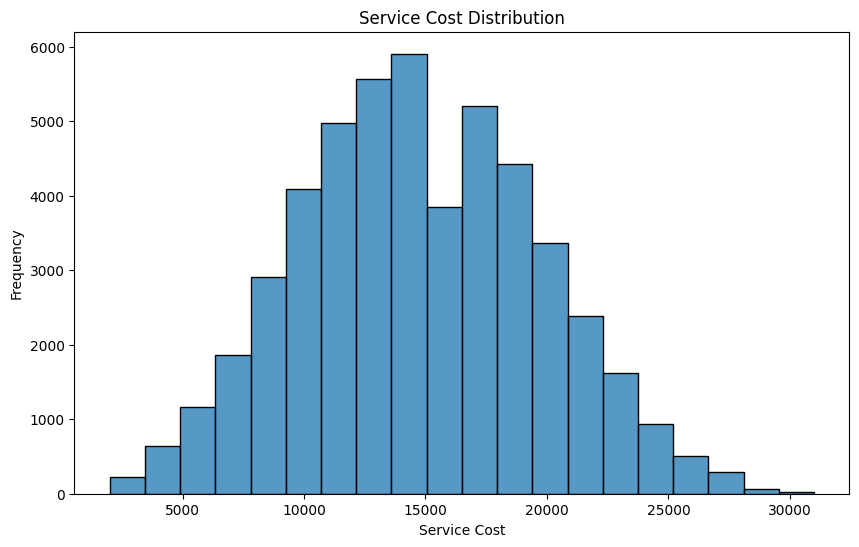

In [19]:
plt.figure(figsize=(10,6))

sns.histplot(
    df['Estimated_Service_Cost'],
    bins=20
)

plt.title("Service Cost Distribution")

plt.xlabel("Service Cost")

plt.ylabel("Frequency")

plt.show()

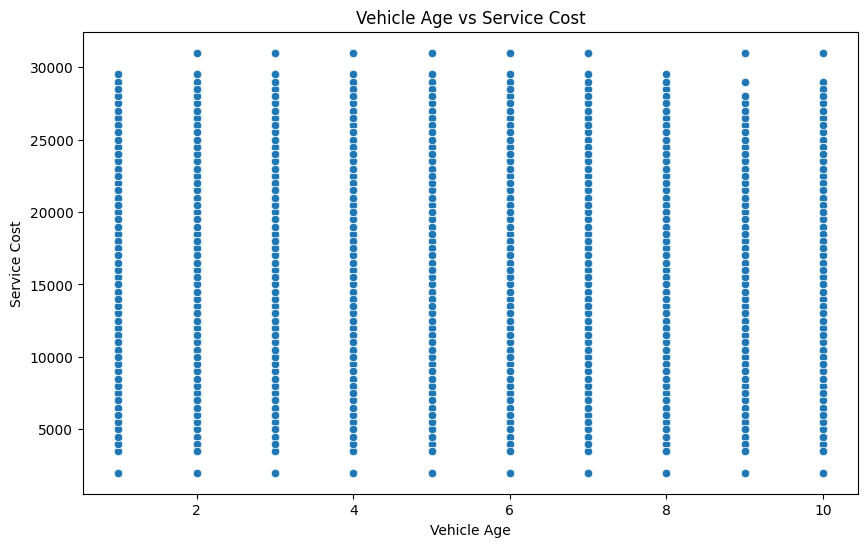

In [20]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df['Vehicle_Age'],
    y=df['Estimated_Service_Cost']
)

plt.title("Vehicle Age vs Service Cost")

plt.xlabel("Vehicle Age")

plt.ylabel("Service Cost")

plt.show()

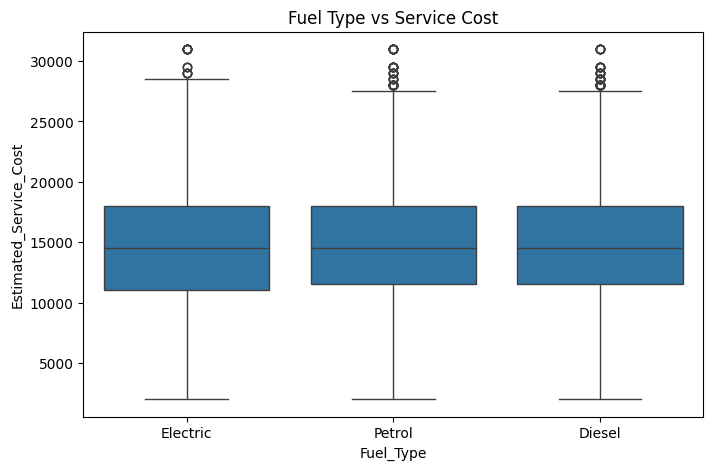

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['Fuel_Type'],
    y=df['Estimated_Service_Cost']
)

plt.title("Fuel Type vs Service Cost")

plt.show()

In [22]:
importance = model.feature_importances_

feature_names = X.columns

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(importance_df)

               Feature  Importance
2      Reported_Issues    0.276089
0              Mileage    0.191370
5  Maintenance_History    0.175824
6      Brake_Condition    0.158807
7       Battery_Status    0.091995
1          Vehicle_Age    0.061709
3            Fuel_Type    0.027553
4    Transmission_Type    0.016653


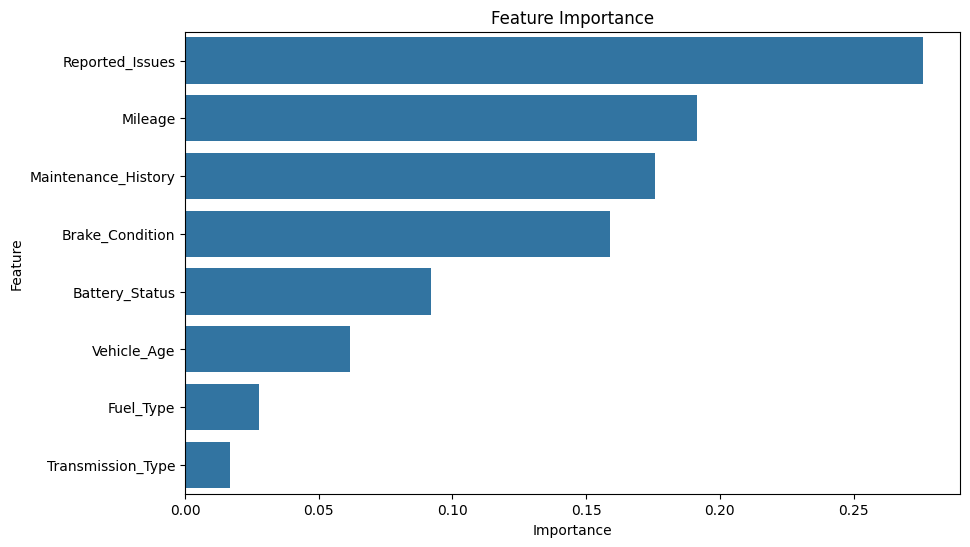

In [24]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance_df
)

plt.title("Feature Importance")

plt.show()

In [25]:
import joblib

joblib.dump(model, "service_cost_model.pkl")

['service_cost_model.pkl']

In [26]:
joblib.dump(label_encoder, "label_encoder.pkl")

['label_encoder.pkl']

In [27]:
import joblib

joblib.dump(model, "service_cost_model.pkl")

['service_cost_model.pkl']

In [28]:
from google.colab import files

files.download("service_cost_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>